# AfyaFlow  Patient Flow Simulation

## Objective

Estimate patient waiting times, queue lengths, resource utilization,
and congestion under forecasted demand and different hospital
capacity scenarios.

**Simulation Inputs**

1. Forecasted patient demand
2. Staff capacity
3. Consultation/service rooms
4. Equipment
5. Bed capacity
6. Service times
7. Patient/service pathways

**Important Assumption**

Resources and service times that are not directly supported by the
available Kijabe data will be treated as simulation assumptions,
not as representations of actual current hospital operations.

### 1. Demand

The simulation will receive forecasted patient demand from the
completed forecasting models.

- Hourly fore-ast →  hort-term operational simulation
- Daily for-cast → 1–7 day simulation
- Weekly fo-ecast → longer-term pavailable.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
forecast = pd.read_csv("daily_future_forecast2.csv")
forecast.head()

,date,QueuedTo,forecast_demand
0,2026-08-20,ADMISSION,50.315600
1,2026-08-20,ANAESTHESIA,0.910797
2,2026-08-20,Audiology,1.333275
3,2026-08-20,CARDIOLOGY,0.264110
4,2026-08-20,CASUALTY,4.029339


### 2. Resource Configuration

The simulation requires resources that constrain patient flow.

Resources are classified according to the strength of evidence supporting
their inclusion and quantity:

- Documented: explicitly supported by available hospital/source material.
- Observed: directly represented in the patient dataset.
- External: obtained from an external source and used only as a benchmark.
- Assumed: introduced as a configurable scenario parameter because the
  available data does not provide the required operational value.

In [5]:
resource_config = pd.DataFrame(columns=["department", "service", "resource_type", "resource_name", "quantity", "evidence_type", "source", "notes"])

resource_config

,department,service,resource_type,resource_name,quantity,evidence_type,source,notes


### 3. Services to be Simulated

The simulation will focus on services that have a meaningful effect on
patient flow and resource utilization.

Services will be selected from the observed `QueuedTo` and
`ConsultDescription` values in the patient dataset.

Not every observed department or service will necessarily be modeled
as a separate simulation pathway. Services will be grouped where
appropriate and expanded only where they represent a distinct
capacity constraint or patient-flow stage.

In [4]:
# General OPD consultation configuration

service_config = pd.DataFrame({"department": ["GENERAL OPD "], "service": ["Consultation"], "service_time_mins": [10], "operating_hours": [8],
    "staff_required_per_patient": [1], "rooms_required_per_patient": [1], "evidence_type": ["Assumed"], "source": ["Simulation assumption"],
    "notes": ["Prototype 1 assumption; replace with documented Kijabe service-time data if available."]})

service_config

,department,service,service_time_mins,operating_hours,staff_required_per_patient,rooms_required_per_patient,evidence_type,source,notes
0,GENERAL OPD,Consultation,10,8,1,1,Assumed,Simulation assumption,Prototype 1 assumption; replace with documente...


In [10]:
# Extract the General OPD forecast for Prototype 1

general_opd_forecast = forecast[forecast["QueuedTo"] == "GENERAL OPD "].copy()

general_opd_forecast = general_opd_forecast[["date", "forecast_demand"]].reset_index(drop=True)

print("General OPD 7 Day Forecast")
print(general_opd_forecast)

General OPD 7 Day Forecast
         date  forecast_demand
0  2026-08-20       123.092936
1  2026-08-21       116.949296
2  2026-08-22        42.408198
3  2026-08-23        30.365127
4  2026-08-24       143.287097
5  2026-08-25       147.061396
6  2026-08-26       133.956492


In [13]:
# general OPD capacity configuration

capacity_config = {
    "department": "GENERAL OPD ", "service": "Consultation",

    # simulation assumptions
    "number_of_staff": 8,
    "number_of_rooms": 6,
    "service_time_mins": 10,
    "operating_hours": 8,

    # evidence classification
    "evidence_type": "Assumed"
}

print("Prototype 1 Capacity Configuration")

for key, value in capacity_config.items():
    print(f"{key}: {value}")

Prototype 1 Capacity Configuration
department: GENERAL OPD 
service: Consultation
number_of_staff: 8
number_of_rooms: 6
service_time_mins: 10
operating_hours: 8
evidence_type: Assumed


In [15]:
# theoretical daily service capacity

service_time = capacity_config["service_time_mins"]
staff = capacity_config["number_of_staff"]
rooms = capacity_config["number_of_rooms"]
operating_hours = capacity_config["operating_hours"]

operating_minutes = operating_hours * 60

# Each patient requires one staff member and one room.
# Therefore the number of simultaneous service slots is limited by the smaller of the two resources.

simultaneous_servers = min(staff, rooms)

capacity_per_day = (simultaneous_servers * operating_minutes) / service_time

print("Theoretical Daily Capacity")
print(f"Operating minutes: {operating_minutes}")
print(f"Simultaneous servers: {simultaneous_servers}")
print(f"Service time: {service_time} minutes")
print(f"Maximum patients/day: {capacity_per_day:.1f}")

Theoretical Daily Capacity
Operating minutes: 480
Simultaneous servers: 6
Service time: 10 minutes
Maximum patients/day: 288.0


In [16]:
#  forecast demand and theoretical capacity comparison

simulation_summary = general_opd_forecast.copy()

simulation_summary["capacity"] = capacity_per_day

simulation_summary["capacity_surplus"] = (simulation_summary["capacity"] - simulation_summary["forecast_demand"])

simulation_summary["capacity_utilization"] = (simulation_summary["forecast_demand"] / simulation_summary["capacity"]) * 100

simulation_summary["unmet_demand"] = (simulation_summary["forecast_demand"] - simulation_summary["capacity"]).clip(lower=0)

print(simulation_summary)

         date  forecast_demand  capacity  capacity_surplus  \
0  2026-08-20       123.092936     288.0        164.907064   
1  2026-08-21       116.949296     288.0        171.050704   
2  2026-08-22        42.408198     288.0        245.591802   
3  2026-08-23        30.365127     288.0        257.634873   
4  2026-08-24       143.287097     288.0        144.712903   
5  2026-08-25       147.061396     288.0        140.938604   
6  2026-08-26       133.956492     288.0        154.043508   

   capacity_utilization  unmet_demand  
0             42.740603           0.0  
1             40.607394           0.0  
2             14.725069           0.0  
3             10.543447           0.0  
4             49.752464           0.0  
5             51.062985           0.0  
6             46.512671           0.0  


In [18]:
df = pd.read_csv("opd_clean.csv")
df.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
1,010575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
2,010575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission
3,010454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care
4,010573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care


In [19]:
# Historical hourly arrival profile for General OPD

general_opd_hourly = df[df["QueuedTo"] == "GENERAL OPD "].copy()
general_opd_hourly["RegistrationDate"] = pd.to_datetime(general_opd_hourly["RegistrationDate"])

general_opd_hourly["hour"] = (general_opd_hourly["RegistrationDate"].dt.hour)

# count historical registrations by hour
hourly_counts = (general_opd_hourly.groupby("hour").size() .reset_index(name="registrations"))

# proportion of daily demand occurring in each hour
hourly_counts["arrival_proportion"] = (hourly_counts["registrations"] / hourly_counts["registrations"].sum())

print(hourly_counts)
print("\nProportion total:")
print(hourly_counts["arrival_proportion"].sum())

    hour  registrations  arrival_proportion
0      0            574            0.006724
1      1            361            0.004229
2      2            219            0.002565
3      3            193            0.002261
4      4            313            0.003666
5      5           1117            0.013085
6      6           2914            0.034135
7      7           7732            0.090573
8      8          12495            0.146366
9      9          13725            0.160775
10    10          10090            0.118194
11    11           8787            0.102931
12    12           6515            0.076317
13    13           4258            0.049878
14    14           3513            0.041151
15    15           3025            0.035435
16    16           2412            0.028254
17    17           1833            0.021472
18    18           1332            0.015603
19    19           1069            0.012522
20    20            931            0.010906
21    21            810         

In [23]:
#  operating hours arrival profile
# sssumed simulation window: 08:00–16:00 (as per provided hours)

operating_start_hour = 8
operating_end_hour = 16   

operating_profile = hourly_counts[(hourly_counts["hour"] >= operating_start_hour) & (hourly_counts["hour"] < operating_end_hour)].copy()


operating_profile["simulation_proportion"] = (operating_profile["arrival_proportion"] / operating_profile["arrival_proportion"].sum())

print("Prototype 1 Operating-Hour Arrival Profile")
print(operating_profile[["hour", "registrations", "arrival_proportion", "simulation_proportion"]])
print("\nSimulation proportion total:", operating_profile["simulation_proportion"].sum())

Prototype 1 Operating-Hour Arrival Profile
    hour  registrations  arrival_proportion  simulation_proportion
8      8          12495            0.146366               0.200215
9      9          13725            0.160775               0.219924
10    10          10090            0.118194               0.161678
11    11           8787            0.102931               0.140799
12    12           6515            0.076317               0.104394
13    13           4258            0.049878               0.068228
14    14           3513            0.041151               0.056291
15    15           3025            0.035435               0.048471

Simulation proportion total: 1.0000000000000002


In [24]:
# generating hourly arrivals from the 7 day forecast

# copy the forecast
hourly_simulation = general_opd_forecast.copy()

# attach the operating hour arrival profile to every forecast day
hourly_simulation = hourly_simulation.merge(operating_profile[["hour", "simulation_proportion"]],how="cross")

# expected arrivals for each hour
hourly_simulation["expected_arrivals"] = (hourly_simulation["forecast_demand"] * hourly_simulation["simulation_proportion"])

# Keep only the columns needed for the simulation
hourly_simulation = hourly_simulation[["date","hour","forecast_demand","simulation_proportion","expected_arrivals"]]

# sort chronologically
hourly_simulation = hourly_simulation.sort_values(["date", "hour"]).reset_index(drop=True)

print("Prototype 1 — Hourly Expected Arrivals")
print("=" * 55)

print(hourly_simulation.head(16))

Prototype 1 — Hourly Expected Arrivals
          date  hour  forecast_demand  simulation_proportion  \
0   2026-08-20     8       123.092936               0.200215   
1   2026-08-20     9       123.092936               0.219924   
2   2026-08-20    10       123.092936               0.161678   
3   2026-08-20    11       123.092936               0.140799   
4   2026-08-20    12       123.092936               0.104394   
5   2026-08-20    13       123.092936               0.068228   
6   2026-08-20    14       123.092936               0.056291   
7   2026-08-20    15       123.092936               0.048471   
8   2026-08-21     8       116.949296               0.200215   
9   2026-08-21     9       116.949296               0.219924   
10  2026-08-21    10       116.949296               0.161678   
11  2026-08-21    11       116.949296               0.140799   
12  2026-08-21    12       116.949296               0.104394   
13  2026-08-21    13       116.949296               0.068228   
1

In [26]:
# verify hourly arrivals equal the daily forecast

daily_check = (hourly_simulation.groupby(["date", "forecast_demand"])["expected_arrivals"].sum().reset_index())

daily_check["difference"] = (daily_check["expected_arrivals"] - daily_check["forecast_demand"])

print(daily_check)

         date  forecast_demand  expected_arrivals    difference
0  2026-08-20       123.092936         123.092936  1.421085e-14
1  2026-08-21       116.949296         116.949296  1.421085e-14
2  2026-08-22        42.408198          42.408198  7.105427e-15
3  2026-08-23        30.365127          30.365127  3.552714e-15
4  2026-08-24       143.287097         143.287097  2.842171e-14
5  2026-08-25       147.061396         147.061396  2.842171e-14
6  2026-08-26       133.956492         133.956492  0.000000e+00


In [27]:
# General OPD Queue Simulation
# Time step: 10 minutes

# simulation parameters
number_of_servers = min(capacity_config["number_of_staff"], capacity_config["number_of_rooms"])

service_time_mins = capacity_config["service_time_mins"]

time_step = 10  # minutes

operating_start = 8
operating_end = 16

# service capacity per time step
capacity_per_step = (number_of_servers * time_step) / service_time_mins

print("Queue Simulation Parameters")
print(f"Servers: {number_of_servers}")
print(f"Service time: {service_time_mins} minutes")
print(f"Time step: {time_step} minutes")
print(f"Capacity per 10-minute step: {capacity_per_step}")

Queue Simulation Parameters
Servers: 6
Service time: 10 minutes
Time step: 10 minutes
Capacity per 10-minute step: 6.0


In [28]:
# queue simulation

simulation_results = []

for date in hourly_simulation["date"].unique():

    day_data = hourly_simulation[
        hourly_simulation["date"] == date].copy()

    # wueue at the beginning of the day
    queue = 0.0

    # track waiting time volume
    total_waiting_patient_minutes = 0.0

    # track total arrivals
    total_arrivals = 0.0

    # track total patients served
    total_served = 0.0

    # track maximum queue
    maximum_queue = 0.0

    # process each hour
    for _, hour_row in day_data.iterrows():

        hour = int(hour_row["hour"])
        hourly_arrivals = hour_row["expected_arrivals"]

        # split hourly arrivals evenly across six 10 minute intervals.
        arrivals_per_step = hourly_arrivals / 6

        # Process each 10-minute interval
        for step in range(6):

            arrivals = arrivals_per_step

            # add new arrivals to queue
            queue += arrivals
            total_arrivals += arrivals

            # patients waiting during this interval
            total_waiting_patient_minutes += queue * time_step

            # patients that can be served
            patients_served = min(queue, capacity_per_step)

            queue -= patients_served
            total_served += patients_served

            # track maximum queue
            maximum_queue = max( maximum_queue, queue)

    # average waiting time
    if total_served > 0:
        average_waiting_time = (total_waiting_patient_minutes / total_served)
    else:
        average_waiting_time = 0

    # capacity utilization
    total_capacity = (number_of_servers * ((operating_end - operating_start) * 60) / service_time_mins)

    utilization = (total_arrivals / total_capacity) * 100

    simulation_results.append({"date": date, "forecast_demand": total_arrivals, "patients_served": total_served, 
                               "patients_remaining": queue, "maximum_queue": maximum_queue, "average_waiting_time_mins": average_waiting_time, 
                               "capacity": total_capacity, "capacity_utilization": utilization})


# convert results to dataframe
simulation_results = pd.DataFrame(simulation_results)

print("Prototype 1 — Queue Simulation Results")
print(simulation_results)

Prototype 1 — Queue Simulation Results
         date  forecast_demand  patients_served  patients_remaining  \
0  2026-08-20       123.092936       123.092936                 0.0   
1  2026-08-21       116.949296       116.949296                 0.0   
2  2026-08-22        42.408198        42.408198                 0.0   
3  2026-08-23        30.365127        30.365127                 0.0   
4  2026-08-24       143.287097       143.287097                 0.0   
5  2026-08-25       147.061396       147.061396                 0.0   
6  2026-08-26       133.956492       133.956492                 0.0   

   maximum_queue  average_waiting_time_mins  capacity  capacity_utilization  
0            0.0                       10.0     288.0             42.740603  
1            0.0                       10.0     288.0             40.607394  
2            0.0                       10.0     288.0             14.725069  
3            0.0                       10.0     288.0             10.543447  
4 

In [37]:
# tuned general OPD Queue Simulation
# Time step: 10 minutes

simulation_results = []
queue_timeline = []

# Simulation parameters
number_of_servers = min(capacity_config["number_of_staff"], capacity_config["number_of_rooms"])

service_time_mins = capacity_config["service_time_mins"]
time_step = 10

operating_start = 8
operating_end = 16

# patients that can be served during one time step
capacity_per_step = (number_of_servers * time_step) / service_time_mins


# simulate each forecast day
for date in hourly_simulation["date"].unique():

    day_data = hourly_simulation[
        hourly_simulation["date"] == date
    ].copy()

    # queue at beginning of day
    queue = 0.0

    total_arrivals = 0.0
    total_served = 0.0

    # area under queue curve
    total_queue_patient_minutes = 0.0

    maximum_queue = 0.0

    # process each hour
    for _, hour_row in day_data.iterrows():

        hour = int(hour_row["hour"])

        hourly_arrivals = hour_row["expected_arrivals"]

        # Six 10-minute intervals in each hour
        arrivals_per_step = hourly_arrivals / 6

        for step in range(6):

            # current simulation time
            current_time = (pd.Timestamp(date) + pd.Timedelta(hours=hour) + pd.Timedelta(minutes=step * time_step))

            # patients arrive
            queue += arrivals_per_step
            total_arrivals += arrivals_per_step

            # measure queue before service
            queue_before_service = queue

            maximum_queue = max(maximum_queue, queue_before_service)
            
            # calculate waiting volume
            total_queue_patient_minutes += (queue_before_service * time_step)

            # serve patients
            patients_served = min(queue, capacity_per_step)

            queue -= patients_served
            total_served += patients_served

            # record timeline
            queue_timeline.append({
                "date": date,
                "time": current_time,
                "hour": hour,
                "arrivals": arrivals_per_step,
                "queue_before_service": queue_before_service,
                "patients_served": patients_served,
                "queue_after_service": queue
            })


    # daily metrics
    patients_remaining = queue

    if total_arrivals > 0:

        # approximate average waiting time
        average_waiting_time = (total_queue_patient_minutes / total_arrivals)

    else:
        average_waiting_time = 0


    # theoretical daily capacity
    total_capacity = (number_of_servers * ((operating_end - operating_start) * 60) / service_time_mins)

    capacity_utilization = (total_arrivals / total_capacity) * 100


    # store daily result
    simulation_results.append({
        "date": date,
        "forecast_demand": total_arrivals,
        "patients_served": total_served,
        "patients_remaining": patients_remaining,
        "maximum_queue": maximum_queue,
        "average_waiting_time_mins": average_waiting_time,
        "capacity": total_capacity,
        "capacity_utilization": capacity_utilization
})


# convert results to a data frame
simulation_results = pd.DataFrame(simulation_results)

queue_timeline = pd.DataFrame(queue_timeline)

# display results
simulation_results

,date,forecast_demand,patients_served,patients_remaining,maximum_queue,average_waiting_time_mins,capacity,capacity_utilization
0,2026-08-20,123.092936,123.092936,0.0,4.511843,10.0,288.0,42.740603
1,2026-08-21,116.949296,116.949296,0.0,4.286654,10.0,288.0,40.607394
2,2026-08-22,42.408198,42.408198,0.0,1.554428,10.0,288.0,14.725069
3,2026-08-23,30.365127,30.365127,0.0,1.113002,10.0,288.0,10.543447
4,2026-08-24,143.287097,143.287097,0.0,5.252039,10.0,288.0,49.752464
5,2026-08-25,147.061396,147.061396,0.0,5.390382,10.0,288.0,51.062985
6,2026-08-26,133.956492,133.956492,0.0,4.910035,10.0,288.0,46.512671


In [34]:
queue_timeline.head(20)

,date,time,hour,arrivals,queue_before_service,patients_served,queue_after_service
0,2026-08-20,2026-08-20 08:00:00,8,4.107503,4.107503,4.107503,0.0
1,2026-08-20,2026-08-20 08:10:00,8,4.107503,4.107503,4.107503,0.0
2,2026-08-20,2026-08-20 08:20:00,8,4.107503,4.107503,4.107503,0.0
3,2026-08-20,2026-08-20 08:30:00,8,4.107503,4.107503,4.107503,0.0
4,2026-08-20,2026-08-20 08:40:00,8,4.107503,4.107503,4.107503,0.0
5,2026-08-20,2026-08-20 08:50:00,8,4.107503,4.107503,4.107503,0.0
6,2026-08-20,2026-08-20 09:00:00,9,4.511843,4.511843,4.511843,0.0
7,2026-08-20,2026-08-20 09:10:00,9,4.511843,4.511843,4.511843,0.0
8,2026-08-20,2026-08-20 09:20:00,9,4.511843,4.511843,4.511843,0.0
9,2026-08-20,2026-08-20 09:30:00,9,4.511843,4.511843,4.511843,0.0


In [41]:
# Prototype 1 Improved General OPD Queue Simulation
# FIFO aggregate queue model
# Time step: 10 minutes

simulation_results = []
queue_timeline = []

# simulation parameters
number_of_servers = min(capacity_config["number_of_staff"], capacity_config["number_of_rooms"])

service_time_mins = capacity_config["service_time_mins"]
time_step = 10

operating_start = 8
operating_end = 16

capacity_per_step = (number_of_servers * time_step) / service_time_mins


# simulate each day
for date in hourly_simulation["date"].unique():

    day_data = hourly_simulation[ hourly_simulation["date"] == date].copy()
    queue = 0.0

    total_arrivals = 0.0
    total_served = 0.0

    total_waiting_patient_minutes = 0.0

    maximum_queue = 0.0

    # process each hour
    for _, hour_row in day_data.iterrows():

        hour = int(hour_row["hour"])

        hourly_arrivals = hour_row["expected_arrivals"]

        # Six 10-minute intervals per hour
        arrivals_per_step = hourly_arrivals / 6


        for step in range(6):

            current_time = (pd.Timestamp(date) + pd.Timedelta(hours=hour) + pd.Timedelta(minutes=step * time_step))
            # new patients arrive
            new_arrivals = arrivals_per_step
            total_arrivals += new_arrivals

            # patients already waiting are served first
            patients_from_queue = min(queue, capacity_per_step)
            queue -= patients_from_queue
            remaining_capacity = (capacity_per_step - patients_from_queue)

            # serve new arrivals if capacity remains
            new_patients_served = min(new_arrivals, remaining_capacity)

            new_arrivals_waiting = (new_arrivals - new_patients_served)

            queue += new_arrivals_waiting

            total_served += (patients_from_queue + new_patients_served)

            # calculate waiting time
            total_waiting_patient_minutes += (queue * time_step)

            # maximum queue
            maximum_queue = max(maximum_queue, queue)

            # record timeline
            queue_timeline.append({
                "date": date,
                "time": current_time,
                "hour": hour,
                "arrivals": new_arrivals,
                "patients_from_queue": patients_from_queue,
                "new_patients_served": new_patients_served,
                "queue_after_service": queue
            })


    # daily capacity
    total_capacity = (number_of_servers * ((operating_end - operating_start) * 60) / service_time_mins)

    # average waiting time
    if total_arrivals > 0:
        average_waiting_time = (total_waiting_patient_minutes/ total_arrivals)
    else:
        average_waiting_time = 0

    # capacity utilization
    capacity_utilization = (total_arrivals / total_capacity) * 100


    # daily result
    simulation_results.append({
        "date": date,
        "forecast_demand": total_arrivals,
        "patients_served": total_served,
        "patients_remaining": queue,
        "maximum_queue": maximum_queue,
        "average_waiting_time_mins": average_waiting_time,
        "capacity": total_capacity,
        "capacity_utilization": capacity_utilization
    })

# convert to data frame
simulation_results = pd.DataFrame(simulation_results)

queue_timeline = pd.DataFrame(queue_timeline)

# display
print("Prototype 1  Improved Queue Simulation")
print(simulation_results)

Prototype 1  Improved Queue Simulation
         date  forecast_demand  patients_served  patients_remaining  \
0  2026-08-20       123.092936       123.092936                 0.0   
1  2026-08-21       116.949296       116.949296                 0.0   
2  2026-08-22        42.408198        42.408198                 0.0   
3  2026-08-23        30.365127        30.365127                 0.0   
4  2026-08-24       143.287097       143.287097                 0.0   
5  2026-08-25       147.061396       147.061396                 0.0   
6  2026-08-26       133.956492       133.956492                 0.0   

   maximum_queue  average_waiting_time_mins  capacity  capacity_utilization  
0            0.0                        0.0     288.0             42.740603  
1            0.0                        0.0     288.0             40.607394  
2            0.0                        0.0     288.0             14.725069  
3            0.0                        0.0     288.0             10.543447  
4 

In [46]:
# Capacity Sensitivity / Scenario Analysis
scenario_results = []

# number of simultaneous consultation servers to test
server_scenarios = [2, 3, 4, 5, 6]

service_time_mins = capacity_config["service_time_mins"]
time_step = 10
operating_start = 8
operating_end = 16

for number_of_servers in server_scenarios:

    capacity_per_step = (number_of_servers * time_step / service_time_mins)

    total_capacity = (number_of_servers * ((operating_end - operating_start) * 60) / service_time_mins)

    for date in hourly_simulation["date"].unique():

        day_data = hourly_simulation[hourly_simulation["date"] == date].copy()

        queue = 0.0
        total_arrivals = 0.0
        total_served = 0.0
        total_waiting_patient_minutes = 0.0
        maximum_queue = 0.0

        for _, hour_row in day_data.iterrows():

            hour = int(hour_row["hour"])
            hourly_arrivals = hour_row["expected_arrivals"]

            # six 10 minute intervals per hour
            arrivals_per_step = hourly_arrivals / 6

            for step in range(6):

                new_arrivals = arrivals_per_step
                total_arrivals += new_arrivals

                # serve patients already waiting
                patients_from_queue = min(queue, capacity_per_step)

                queue -= patients_from_queue

                # remaining capacity
                remaining_capacity = (capacity_per_step - patients_from_queue)

                # serve newly arrived patients
                new_patients_served = min(new_arrivals,remaining_capacity)
                
                # patients who cannot be served wait
                new_arrivals_waiting = (new_arrivals - new_patients_served)
                queue += new_arrivals_waiting
                total_served += (patients_from_queue + new_patients_served)
                # waiting patient minutes
                total_waiting_patient_minutes += (queue * time_step)
                maximum_queue = max(maximum_queue, queue)

        # calculate average waiting time
        if total_arrivals > 0:
            average_waiting_time = (total_waiting_patient_minutes / total_arrivals)
        else:
            average_waiting_time = 0

        capacity_utilization = (total_arrivals / total_capacity * 100)

        scenario_results.append({
            "date": date,
            "servers": number_of_servers,
            "forecast_demand": total_arrivals,
            "patients_served": total_served,
            "patients_remaining": queue,
            "maximum_queue": maximum_queue,
            "average_waiting_time_mins": average_waiting_time,
            "capacity": total_capacity,
            "capacity_utilization": capacity_utilization
        })


# convert to data frame
scenario_results = pd.DataFrame(scenario_results)

print("Prototype 1 Capacity Sensitivity Analysis")
scenario_results.round(2)

Prototype 1 Capacity Sensitivity Analysis


,date,servers,forecast_demand,patients_served,patients_remaining,maximum_queue,average_waiting_time_mins,capacity,capacity_utilization
0,2026-08-20,2,123.09,96.00,27.09,41.80,119.84,96.0,128.22
1,2026-08-21,2,116.95,96.00,20.95,36.72,109.80,96.0,121.82
2,2026-08-22,2,42.41,42.41,0.00,0.00,0.00,96.0,44.18
3,2026-08-23,2,30.37,30.37,0.00,0.00,0.00,96.0,31.63
4,2026-08-24,2,143.29,96.00,47.29,58.50,146.77,96.0,149.26
5,2026-08-25,2,147.06,96.00,51.06,61.62,150.98,96.0,153.19
6,2026-08-26,2,133.96,96.00,37.96,50.78,135.33,96.0,139.54
7,2026-08-20,3,123.09,123.09,0.00,17.62,34.15,144.0,85.48
8,2026-08-21,3,116.95,116.95,0.00,14.04,26.02,144.0,81.21
9,2026-08-22,3,42.41,42.41,0.00,0.00,0.00,144.0,29.45


In [51]:
# Congestion Status Thresholds
def assign_congestion_status(row):

    if row["patients_remaining"] > 0:
        return "Critical"

    elif row["capacity_utilization"] > 100:
        return "Overloaded"

    elif row["capacity_utilization"] >= 85:
        return "High"

    elif row["capacity_utilization"] >= 70:
        return "Moderate"

    else:
        return "Low"


# apply status labels
scenario_results["status"] = scenario_results.apply(assign_congestion_status, axis=1)

# display results
scenario_results.round(2)

,date,servers,forecast_demand,patients_served,patients_remaining,maximum_queue,average_waiting_time_mins,capacity,capacity_utilization,status
0,2026-08-20,2,123.09,96.00,27.09,41.80,119.84,96.0,128.22,Critical
1,2026-08-21,2,116.95,96.00,20.95,36.72,109.80,96.0,121.82,Critical
2,2026-08-22,2,42.41,42.41,0.00,0.00,0.00,96.0,44.18,Low
3,2026-08-23,2,30.37,30.37,0.00,0.00,0.00,96.0,31.63,Low
4,2026-08-24,2,143.29,96.00,47.29,58.50,146.77,96.0,149.26,Critical
5,2026-08-25,2,147.06,96.00,51.06,61.62,150.98,96.0,153.19,Critical
6,2026-08-26,2,133.96,96.00,37.96,50.78,135.33,96.0,139.54,Critical
7,2026-08-20,3,123.09,123.09,0.00,17.62,34.15,144.0,85.48,High
8,2026-08-21,3,116.95,116.95,0.00,14.04,26.02,144.0,81.21,Moderate
9,2026-08-22,3,42.41,42.41,0.00,0.00,0.00,144.0,29.45,Low


In [50]:
row = scenario_results.loc[12]   
row

date                         2026-08-25
servers                               3
forecast_demand              147.061396
patients_served                   144.0
patients_remaining             3.061396
maximum_queue                 34.268872
average_waiting_time_mins     71.013861
capacity                          144.0
capacity_utilization         102.125969
status                         Critical
Name: 12, dtype: object

General OPD Queue Simulation
Date: 25 August 2026
Servers: 3
Forecast demand: 147.06
Maximum queue: 34.27
Patients remaining: 3.06


,time,new_arrivals,patients_served,queue
0,2026-08-25 08:00:00,4.91,3.0,1.91
1,2026-08-25 08:10:00,4.91,3.0,3.81
2,2026-08-25 08:20:00,4.91,3.0,5.72
3,2026-08-25 08:30:00,4.91,3.0,7.63
4,2026-08-25 08:40:00,4.91,3.0,9.54
5,2026-08-25 08:50:00,4.91,3.0,11.44
6,2026-08-25 09:00:00,5.39,3.0,13.83
7,2026-08-25 09:10:00,5.39,3.0,16.22
8,2026-08-25 09:20:00,5.39,3.0,18.62
9,2026-08-25 09:30:00,5.39,3.0,21.01


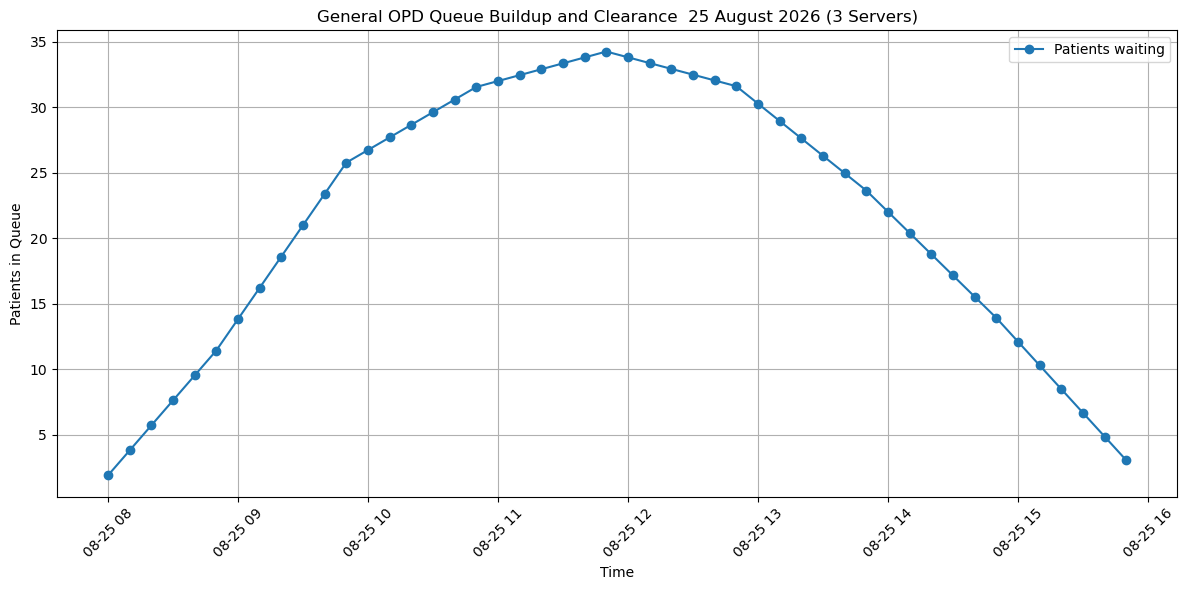

In [66]:
# Queue buildup and clearance
# Date: 2026-08-25
# Scenario: 3 consultation servers

target_date = "2026-08-25"
# prep the date column
hourly_simulation["date"] = pd.to_datetime(hourly_simulation["date"]).dt.normalize()

target_date = pd.Timestamp(target_date)

# forecast for the selected day
day_data = hourly_simulation[hourly_simulation["date"] == target_date].copy()

# data verification
if day_data.empty:
    print("ERROR: No hourly simulation data found for", target_date)
    print("Available dates:")
    print(hourly_simulation["date"].drop_duplicates().sort_values().tail(10))

else:

    # simulation parameters
    number_of_servers = 3
    service_time_mins = 10
    time_step = 10

    capacity_per_step = (number_of_servers* time_step / service_time_mins)

    queue = 0.0
    timeline = []

    # simulate the day
    for _, hour_row in day_data.iterrows():

        hour = int(hour_row["hour"])
        hourly_arrivals = hour_row["expected_arrivals"]

        # Divide hourly arrivals into six 10-minute periods
        arrivals_per_step = hourly_arrivals / 6

        for step in range(6):

            current_time = (target_date + pd.Timedelta(hours=hour) + pd.Timedelta(minutes=step * time_step)            )

            new_arrivals = arrivals_per_step

            # serve patients already waiting
            patients_from_queue = min(queue, capacity_per_step)
            queue -= patients_from_queue

            # use remaining capacity for new arrivals
            remaining_capacity = (capacity_per_step - patients_from_queue)

            new_patients_served = min(new_arrivals,remaining_capacity)

            # patients who cannot be served wait
            new_arrivals_waiting = (new_arrivals - new_patients_served)

            queue += new_arrivals_waiting

            # store the simulation state
            timeline.append({"time": current_time, "new_arrivals": new_arrivals, "patients_served": (patients_from_queue + new_patients_served),"queue": queue})

    # timeline to DataFrame
    queue_day = pd.DataFrame(timeline)

    # summary
    print("General OPD Queue Simulation")
    print(f"Date: {target_date.strftime('%d %B %Y')}")
    print(f"Servers: {number_of_servers}")
    print(f"Forecast demand: "f"{queue_day['new_arrivals'].sum():.2f}")
    print(f"Maximum queue: "f"{queue_day['queue'].max():.2f}")
    print(f"Patients remaining: "f"{queue_day['queue'].iloc[-1]:.2f}")
    
    display(queue_day.round(2))

    # plot queue
    plt.figure(figsize=(12, 6))
    plt.plot(queue_day["time"], queue_day["queue"], marker="o", label="Patients waiting")
    plt.xlabel("Time")
    plt.ylabel("Patients in Queue")
    plt.title(
        "General OPD Queue Buildup and Clearance  " "25 August 2026 (3 Servers)")

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()